# Original code

In [63]:
import gamdpy as gp
import h5py

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os.path

gp.select_gpu()

# Specify statepoint
num_part = 8000
rho = 1.200
temperature = 5.00
qA = 0.5
qB = -4*qA # (4:1 mixture)

# Setup configuration: 
configuration = gp.Configuration(D=3, compute_flags={'U': True, 'K': True})
configuration.make_positions(N=num_part, rho=rho)
configuration['m'] = 1.0 # Specify all masses to unity 
configuration.randomize_velocities(temperature=temperature, seed=1) # Initial high temperature for randomizing
configuration.ptype[::5] = 1 # Every fifth particle set to type 1 (4:1 mixture)

# Setup pair potential: Binary Kob-Andersen LJ mixture + coulomb.
LJ_Coulomb = gp.add_potential_functions(gp.LJ_12_6_sigma_epsilon, gp.make_IPL_n(1,first_parameter=2))
pair_func = gp.apply_shifted_force_cutoff(LJ_Coulomb)
sig = [[1.00, 0.80],
       [0.80, 0.88]]
eps = [[1.00, 1.50],
       [1.50, 0.50]]
qq = [[ qA*qA, qA*qB],
      [ qB*qA, qB*qB]]
cut = [[ 6, 6],
       [ 6, 6]]
pair_pot = gp.PairPotential(pair_func, params=[sig, eps, qq, cut], max_num_nbs=2000)

dt = 0.004  # timestep
num_timeblocks = 64           # Do simulation in this many 'blocks'. 
steps_per_timeblock = 1*1024  # ... each of this many steps

integrator = gp.integrators.NVT(temperature=temperature, tau=0.2, dt=dt)

# Setup runtime actions, i.e. actions performed during simulation of timeblocks
calc_rdf = gp.CalculatorRadialDistribution(configuration, bins=500)
runtime_actions = [gp.TrajectorySaver(), gp.RestartSaver(), gp.ScalarSaver(32), gp.MomentumReset(100)]

compute_plan = gp.get_default_compute_plan(configuration)
compute_plan['nblist'] = 'N squared'
print(compute_plan)
sim = gp.Simulation(configuration, pair_pot, integrator, runtime_actions, 
                    num_timeblocks=num_timeblocks, steps_per_timeblock=steps_per_timeblock,
                    compute_plan=compute_plan, storage="memory") 

# Equilibration
print('Equilibrating.............')
for block in sim.run_timeblocks():
    pass
print(sim.summary())
        
# Production
print('Running............')
for block in sim.run_timeblocks():
    calc_rdf.update()
    print(f'{sim.status(per_particle=True)}')
print(sim.summary())

Using device 0
{'pb': 32, 'tp': 2, 'skin': np.float32(1.0), 'UtilizeNIII': False, 'gridsync': True, 'nblist': 'N squared'}
Equilibrating.............
Particles : 8000 
Steps : 64 * 1024 = 65_536 
Total run time  (incl. time spent between timeblocks): 71.60 s ( TPS: 9.15e+02 )
Simulation time (excl. time spent between timeblocks): 68.33 s ( TPS: 9.59e+02 )

Running............
timeblock= 0     time= 4.096       U= -3.152    W= 27.214    K= 7.533     
timeblock= 1     time= 8.192       U= -3.155    W= 27.222    K= 7.530     
timeblock= 2     time= 12.288      U= -3.200    W= 26.910    K= 7.451     
timeblock= 3     time= 16.384      U= -3.095    W= 27.495    K= 7.544     
timeblock= 4     time= 20.480      U= -3.174    W= 27.040    K= 7.537     
timeblock= 5     time= 24.576      U= -3.105    W= 27.454    K= 7.488     
timeblock= 6     time= 28.672      U= -3.166    W= 27.131    K= 7.595     
timeblock= 7     time= 32.768      U= -3.240    W= 26.725    K= 7.504     
timeblock= 8     time

In [22]:
gp.tools.print_h5_structure(sim.output)

initial_configuration/ (Group)
    ptype  (Dataset, shape=(8000,), dtype=int32)
    r_im  (Dataset, shape=(8000, 3), dtype=int32)
    scalars  (Dataset, shape=(8000, 4), dtype=float32)
    topology/ (Group)
        angles  (Dataset, shape=(0,), dtype=int32)
        bonds  (Dataset, shape=(0,), dtype=int32)
        dihedrals  (Dataset, shape=(0,), dtype=int32)
        molecules/ (Group)
    vectors  (Dataset, shape=(3, 8000, 3), dtype=float32)
restarts/ (Group)
    restart0000/ (Group)
        ptype  (Dataset, shape=(8000,), dtype=int32)
        r_im  (Dataset, shape=(8000, 3), dtype=int32)
        scalars  (Dataset, shape=(8000, 4), dtype=float32)
        topology/ (Group)
            angles  (Dataset, shape=(0,), dtype=int32)
            bonds  (Dataset, shape=(0,), dtype=int32)
            dihedrals  (Dataset, shape=(0,), dtype=int32)
            molecules/ (Group)
        vectors  (Dataset, shape=(3, 8000, 3), dtype=float32)
    restart0001/ (Group)
        ptype  (Dataset, shape=(8

In [64]:
tmp = gp.tools.calc_dynamics(sim.output, 0, qvalues=2*np.pi)
t1, msd1 = [tmp[key] for key in ['times', 'msd']]

In [65]:
tmp = calc_rdf.read()
r1, rdf1 = [tmp[key] for key in ['distances', 'rdf']]

In [66]:
U1, K1 = gp.ScalarSaver.extract(sim.output, ['U', 'K'], per_particle=True)

# New stuff

In [67]:
# Setup configuration: 
c2 = gp.Configuration(D=3, compute_flags={'U': True, 'K': True})
c2.make_positions(N=num_part, rho=rho)
c2['m'] = 1.0 # Specify all masses to unity 
c2.randomize_velocities(temperature=temperature, seed=1) # Initial high temperature for randomizing
c2.ptype[::5] = 1 # Every fifth particle set to type 1 (4:1 mixture)

# Setup pair potential: Binary Kob-Andersen LJ mixture + coulomb.
charges = [qA, qB]
LJ = gp.apply_shifted_force_cutoff(gp.LJ_12_6_sigma_epsilon)
LJ_pair = gp.PairPotential(LJ, params=[sig, eps, cut], max_num_nbs=2000)
Coulomb = gp.Electrostatics(charges=charges, cutoff=cut)

integrator = gp.integrators.NVT(temperature=temperature, tau=0.2, dt=dt)

# Setup runtime actions, i.e. actions performed during simulation of timeblocks
calc_rdf = gp.CalculatorRadialDistribution(c2, bins=500)
runtime_actions = [gp.TrajectorySaver(), gp.RestartSaver(), gp.ScalarSaver(32), gp.MomentumReset(100)]

compute_plan = gp.get_default_compute_plan(configuration)

sim2 = gp.Simulation(c2, [LJ_pair, Coulomb], integrator, runtime_actions, 
                    num_timeblocks=num_timeblocks, steps_per_timeblock=steps_per_timeblock,
                    compute_plan=compute_plan, storage="memory") 

# Equilibration
print('Equilibrating.............')
for block in sim2.run_timeblocks():
    pass
print(sim2.summary())
        
# Production
print('Running............')
for block in sim2.run_timeblocks():
    calc_rdf.update()
    print(f'{sim2.status(per_particle=True)}')
print(sim2.summary())

Equilibrating.............
Particles : 8000 
Steps : 64 * 1024 = 65_536 
Total run time  (incl. time spent between timeblocks): 199.92 s ( TPS: 3.28e+02 )
Simulation time (excl. time spent between timeblocks): 196.70 s ( TPS: 3.33e+02 )

Running............
timeblock= 0     time= 4.096       U= -3.139    W= 27.293    K= 7.550     
timeblock= 1     time= 8.192       U= -3.108    W= 27.383    K= 7.473     
timeblock= 2     time= 12.288      U= -3.120    W= 27.365    K= 7.525     
timeblock= 3     time= 16.384      U= -3.167    W= 27.121    K= 7.492     
timeblock= 4     time= 20.480      U= -3.150    W= 27.254    K= 7.560     
timeblock= 5     time= 24.576      U= -3.096    W= 27.462    K= 7.386     
timeblock= 6     time= 28.672      U= -3.192    W= 26.967    K= 7.422     
timeblock= 7     time= 32.768      U= -3.177    W= 27.079    K= 7.513     
timeblock= 8     time= 36.864      U= -3.161    W= 27.150    K= 7.567     
timeblock= 9     time= 40.960      U= -3.205    W= 27.017    K= 7.5

In [68]:
tmp = gp.tools.calc_dynamics(sim2.output, 0, qvalues=2*np.pi)
t2, msd2 = [tmp[key] for key in ['times', 'msd']]

In [69]:
tmp = calc_rdf.read()
r2, rdf2 = [tmp[key] for key in ['distances', 'rdf']]

In [70]:
U2, K2 = gp.ScalarSaver.extract(sim2.output, ['U', 'K'], per_particle=True)

# Comparison

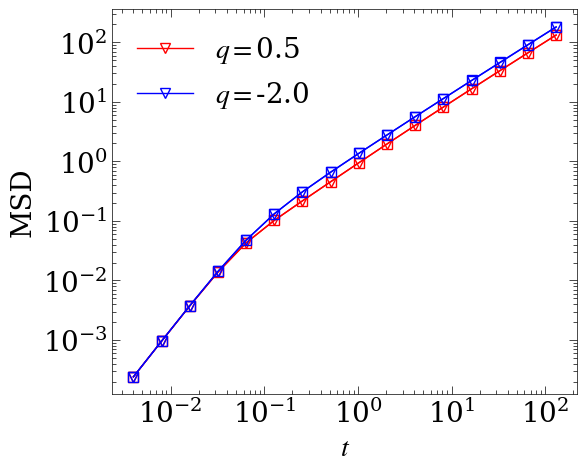

In [74]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator
plt.style.use('physrev')

colors=['r','b']

for typ in range(2):
    plt.loglog(t1, msd1[:, typ], label=r'$q=$' + f'{charges[typ]:.1f}', color=colors[typ])
    plt.loglog(t2, msd2[:, typ], marker='s', color=colors[typ])
plt.xlabel(r'$t$')
plt.ylabel(r'MSD')
plt.legend(frameon=False)

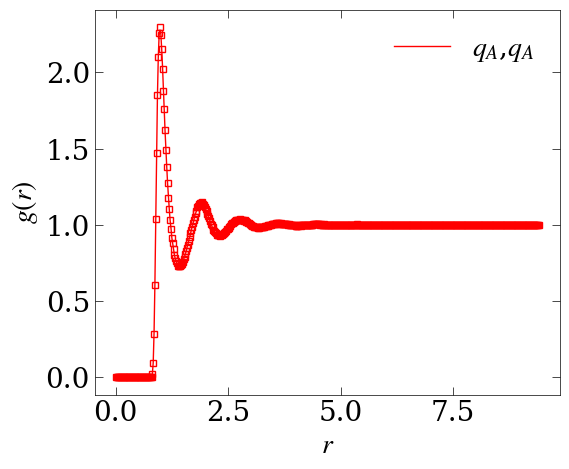

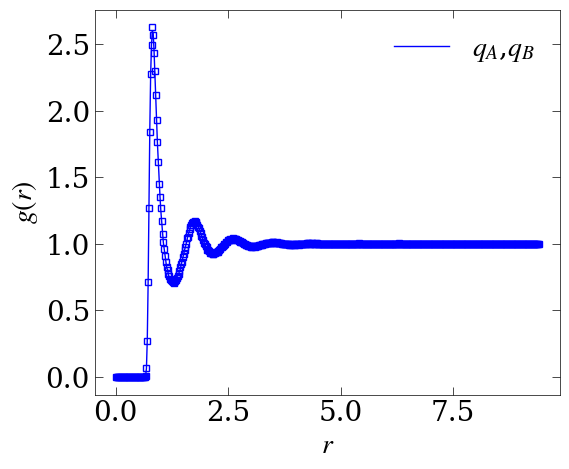

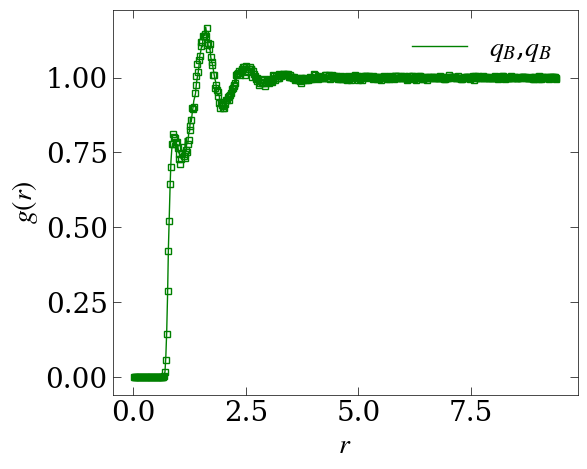

In [92]:
colors=['r','b', 'm', 'g']
labels = [r'$q_A$', r'$q_B$']
idx = 0
for typ1 in range(2):
    for typ2 in range(2):
        if typ1 == 1 and typ2 == 0:
            pass
        else:
            plt.plot(r1, rdf1[:, typ1, typ2], label=labels[typ1]+','+labels[typ2], marker='none', color=colors[idx])
            plt.plot(r2, rdf2[:, typ1, typ2], marker='s', ls='none', ms=4, color=colors[idx])
            plt.xlabel(r'$r$')
            plt.ylabel(r'$g(r)$')
            plt.legend(frameon=False)
            plt.show()
        idx += 1

In [88]:
print(np.mean(U1), np.mean(U2))

-3.1547427 -3.155939


In [89]:
print(np.mean(K1), np.mean(K2))

7.497918 7.4978905
